In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import textwrap

# Company Overview: Apple Inc

In [2]:
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)
info = ticker.info

print("=" * 50)
print(f"Ticker        : {ticker_symbol}")
print(f"Company Name  : {info.get('longName', 'N/A')}")
print(f"Sector        : {info.get('sector', 'N/A')}")
print(f"Industry      : {info.get('industry', 'N/A')}")

# Market Cap
market_cap = info.get("marketCap", 0)
if market_cap >= 10e9:
    cap_category = "Large Cap (>$10B)"
elif market_cap >= 2e9:
    cap_category = "Mid Cap ($2B–$10B)"
else:
    cap_category = "Small Cap (<$2B)"

print(f"\nMarket Cap    : ${market_cap:,.0f}  →  {cap_category}")
print(f"Data Source   : yfinance")
print("=" * 50)

Ticker        : AAPL
Company Name  : Apple Inc.
Sector        : Technology
Industry      : Consumer Electronics

Market Cap    : $3,656,844,050,432  →  Large Cap (>$10B)
Data Source   : yfinance


## Information about the Database

In [3]:
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2024-12-31")
# Flatten MultiIndex columns if present (yfinance quirk)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

C:\Users\rasul\AppData\Local\Temp\ipykernel_13188\451366485.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,178.103653,178.954991,173.895953,174.013372,104487900
2022-01-04,175.843201,179.013668,175.275647,178.710324,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308487,171.537664,167.956213,168.993460,96904000
2022-01-07,168.474838,170.402559,167.359306,169.179387,86709100


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 752 entries, 2022-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   752 non-null    float64
 1   High    752 non-null    float64
 2   Low     752 non-null    float64
 3   Open    752 non-null    float64
 4   Volume  752 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.2 KB


In [5]:
df.describe()

Price,Close,High,Low,Open,Volume
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.930894,177.602214,174.054116,175.737403,6.811545e+07
std,29.379631,29.301145,29.325772,29.304616,2.834590e+07
min,123.046814,125.753411,122.210219,124.021194,2.323470e+07
25%,153.364712,155.061751,151.123533,152.832389,4.877432e+07
50%,171.176895,172.192433,169.397021,170.829569,6.224455e+07
75%,189.577976,190.982797,188.283321,189.460077,8.059140e+07
max,257.612732,258.686881,256.230300,256.787255,3.186799e+08


In [6]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

## Price Data

In [7]:
# Flatten MultiIndex columns if present (yfinance quirk)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 52-Week High / Low
high_52 = df["Close"].tail(252).max()
low_52  = df["Close"].tail(252).min()
last_close = df["Close"].iloc[-1]

print("=" * 50)
print(f"OHLCV Shape   : {df.shape}  (rows × columns)")
print(f"\nLatest row:\n{df.tail(1).to_string()}")
print(f"\n52-Week High  : ${high_52:.2f}")
print(f"52-Week Low   : ${low_52:.2f}")
print(f"Last Close    : ${last_close:.2f}")
pct_from_high = (last_close - high_52) / high_52 * 100
print(f"From 52W High : {pct_from_high:.1f}%")
print("=" * 50)

# ── How to read this ──────────────────────────────────────
# 52-Week High/Low is one of the most watched indicators:
#   → Price near the HIGH  → momentum, potential breakout
#   → Price near the LOW   → weakness, or potential value
#   → "% from 52W High" tells you how far off the peak you are

OHLCV Shape   : (752, 5)  (rows × columns)

Latest row:
Price            Close        High         Low        Open    Volume
Date                                                                
2024-12-30  250.829788  252.122728  249.387669  250.859624  35557500

52-Week High  : $257.61
52-Week Low   : $163.51
Last Close    : $250.83
From 52W High : -2.6%


## Return Analysis

In [8]:
df["Daily Return"]        = df["Close"].pct_change()
df["Cumulative Return"]   = (1 + df["Daily Return"]).cumprod() - 1

total_return     = df["Cumulative Return"].iloc[-1]
trading_days     = df["Daily Return"].count()
annualized_ret   = (1 + total_return) ** (252 / trading_days) - 1

print(f"Total Return      : {total_return*100:.2f}%")
print(f"Annualised Return : {annualized_ret*100:.2f}%")
print(f"Trading Days      : {trading_days}")

Total Return      : 40.83%
Annualised Return : 12.18%
Trading Days      : 751


### Daily Return

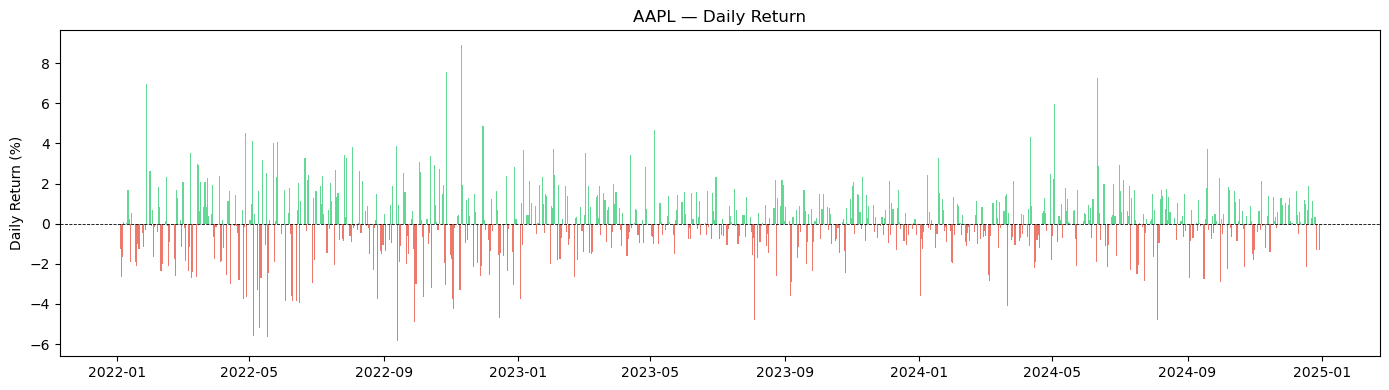

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["Daily Return"] * 100,
       color=df["Daily Return"].apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
       width=1, alpha=0.75)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_title(f"{ticker_symbol} — Daily Return")
ax.set_ylabel("Daily Return (%)")

plt.tight_layout()
plt.show()

# Green bar  = up day   | Red bar = down day
# Tall bars  = big move (earnings, news, macro)
# Tiny bars  = quiet day, low volatility

### Cumulative Return

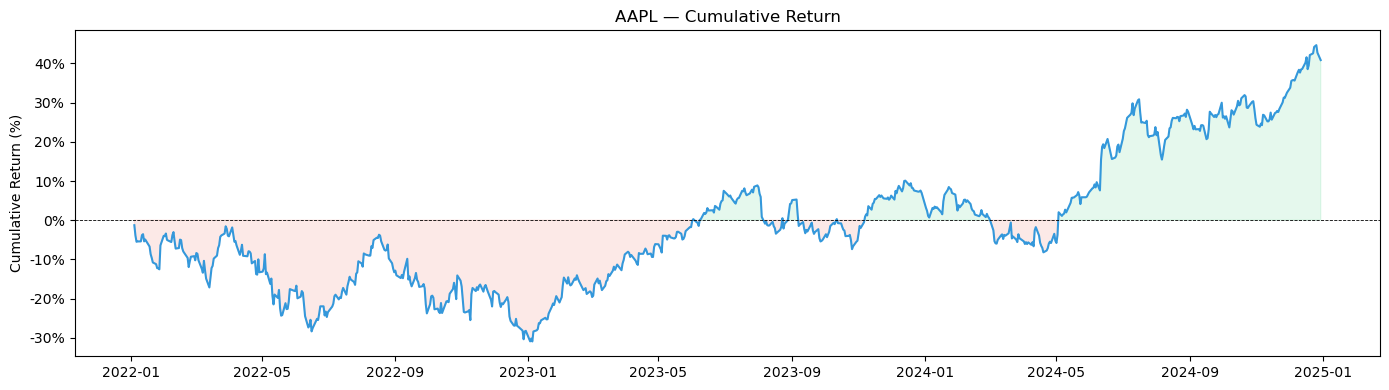

In [61]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Cumulative Return"] * 100,
        color="#3498db", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.fill_between(df.index, df["Cumulative Return"] * 100, 0,
                where=df["Cumulative Return"] >= 0, alpha=0.12, color="#2ecc71")
ax.fill_between(df.index, df["Cumulative Return"] * 100, 0,
                where=df["Cumulative Return"] < 0,  alpha=0.12, color="#e74c3c")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(f"{ticker_symbol} — Cumulative Return")
ax.set_ylabel("Cumulative Return (%)")

plt.tight_layout()
plt.show()

# Rising line       = stock gaining over the period
# Steep dip + climb = drawdown and recovery
# Green shading     = in profit from start date
# Red shading       = in loss from start date

## Volatility

In [ ]:
WINDOW = 30 # How many days we're looking back at

df["Rolling Vol"]     = df["Daily Return"].rolling(WINDOW).std()
df["Ann. Rolling Vol"] = df["Rolling Vol"] * np.sqrt(252)

overall_ann_vol = df["Daily Return"].std() * np.sqrt(252) # Volatility of the whole period

print(f"Overall Annualised Volatility : {overall_ann_vol*100:.2f}%")
print(f"Rolling window                : {WINDOW} trading days")

Overall Annualised Volatility : 27.11%
Rolling window                : 30 trading days


### Rolling 30-Day Volatility (Daily Std)

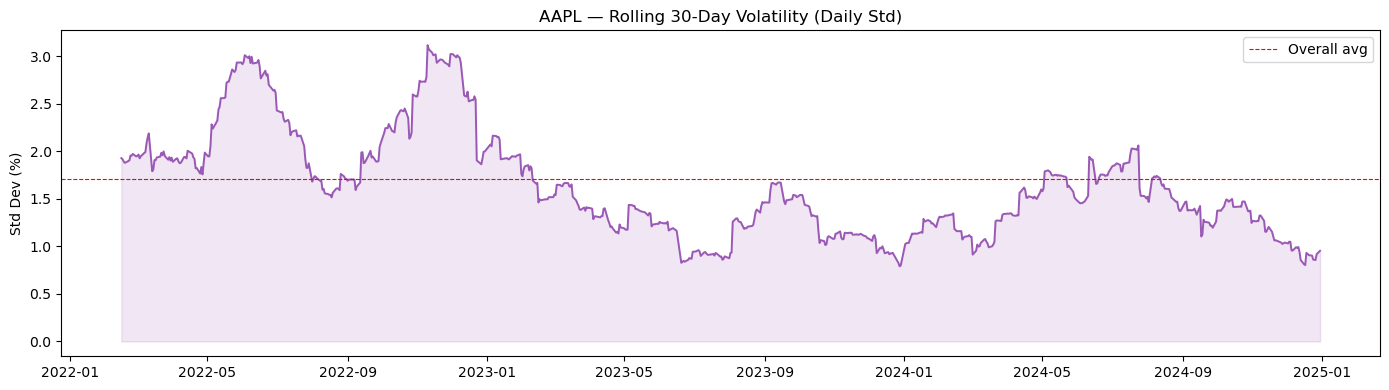

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Rolling Vol"] * 100,
        color="#9b59b6", linewidth=1.4)
ax.fill_between(df.index, df["Rolling Vol"] * 100,
                alpha=0.15, color="#9b59b6")
ax.axhline(df["Daily Return"].std() * 100, color="red",
           linewidth=0.8, linestyle="--", label="Overall avg")
ax.set_title(f"{ticker_symbol} — Rolling {WINDOW}-Day Volatility (Daily Std)")
ax.set_ylabel("Std Dev (%)")
ax.legend()

plt.tight_layout()
plt.show()

# Peak    = turbulent period (rate hikes, earnings fear)
# Trough  = calm, low-uncertainty market
# Red line = your baseline — spikes above it are notable

### Annualised Rolling 30-Day Volatility

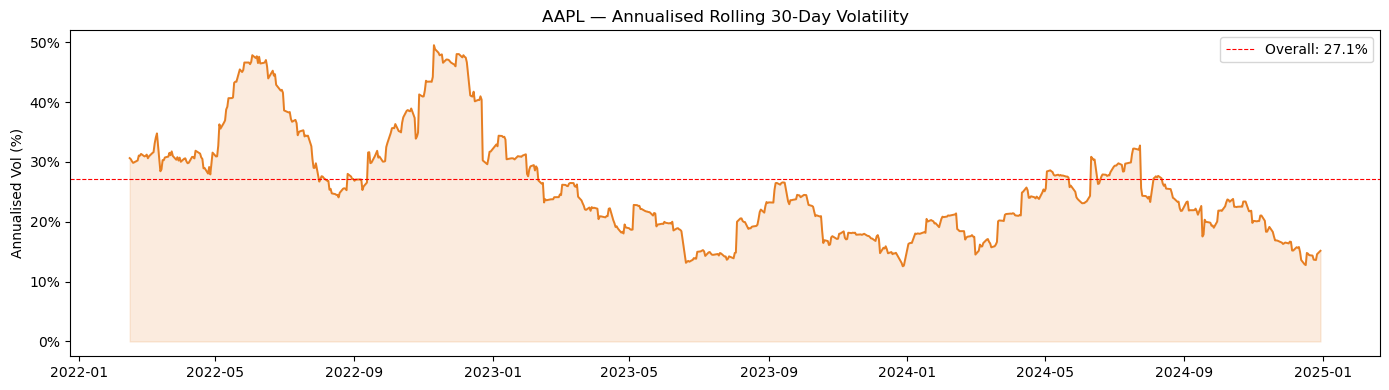

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["Ann. Rolling Vol"] * 100,
        color="#e67e22", linewidth=1.4)
ax.fill_between(df.index, df["Ann. Rolling Vol"] * 100,
                alpha=0.15, color="#e67e22")
ax.axhline(overall_ann_vol * 100, color="red",
           linewidth=0.8, linestyle="--",
           label=f"Overall: {overall_ann_vol*100:.1f}%")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_title(f"{ticker_symbol} — Annualised Rolling {WINDOW}-Day Volatility")
ax.set_ylabel("Annualised Vol (%)")
ax.legend()

plt.tight_layout()
plt.show()

# Scale is now yearly % — e.g. 30% means ±30% expected swing/year
# AAPL typically sits 25–35% annualised vol
# Spikes above 40%+ = exceptional turbulence
# This is the number used in options pricing

## Technical Indicators

### Calculations

In [ ]:
# --- SMA ---
df["SMA_20"]  = df["Close"].rolling(20).mean() # Mean of each 20 day window
df["SMA_50"]  = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

# --- EMA ---
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean() #ewm stands for Exponential Weighted Mean, span = 12 is the value for N in the formula k = 2/(N+1)
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean() # adjust = False uses the recursive formula (each day's EMA depends on the previous day's EMA)

# --- RSI ---
delta       = df["Close"].diff() # .diff() subtracts previous row from current row, todays close - yesterdays close
gain        = delta.clip(lower=0).rolling(14).mean() # .clip(lower=0) forces all negative values to 0. keeps only the up days, zeroes out the down days, rolling(14).mean() averages those gains over 14 days.
loss        = -delta.clip(upper=0).rolling(14).mean() # .clip(upper=0) forces all positive values to 0. keeps only the down days (negative numbers), zeroes out the up days. The - at the front flips the negatives to positives so the loss value is a positive number. Then average over 14 days.
df["RSI"]   = 100 - (100 / (1 + gain / loss)) # gain/loss = relative strength. 100/(1+RS) shrinks as RS grows. 100-... flips it so high RS gives high RSI

# --- MACD ---
df["MACD"]        = df["EMA_12"] - df["EMA_26"] # subtracts the two EMA columns already calculated. Positive = short-term momentum above long-term. Negative = below.
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean() # Takes the MACD column and applies another EMA, this time with span=9 to smooth it. This is the Signal Line. (applied to MACD values instead of price)
df["MACD_Hist"]   = df["MACD"] - df["MACD_Signal"] # Subtracts Signal from MACD. Positive = MACD is above Signal = bullish. Negative = MACD is below Signal = bearish. This is what the histogram bars represent.

# --- Bollinger Bands ---
df["BB_Mid"]   = df["Close"].rolling(20).mean() # Exactly the same as SMA_20 — the middle band is just the 20-day average.
df["BB_Std"]   = df["Close"].rolling(20).std() # measures how spread out the last 20 closing prices are around their mean. Small value = prices clustered tightly = bands narrow. Large value = prices spread out = bands wide.
df["BB_Upper"] = df["BB_Mid"] + 2 * df["BB_Std"] # Adds/subtracts 2 standard deviations from the middle band. 2 is the standard choice because statistically 95% of values fall within 2 standard deviations of the mean. 
df["BB_Lower"] = df["BB_Mid"] - 2 * df["BB_Std"] # You could use 1.5 for tighter bands or 2.5 for wider ones, but 2 is the convention.

print("Technical indicators calculated:")
print(df[["Close", "SMA_20", "SMA_50", "SMA_200",
          "RSI", "MACD", "MACD_Signal", "BB_Upper", "BB_Lower"]].tail())

Technical indicators calculated:
Price            Close      SMA_20      SMA_50     SMA_200        RSI  \
Date                                                                    
2024-12-23  253.883118  243.695760  234.001648  209.838113  73.865411   
2024-12-24  256.797211  244.955380  234.541781  210.266139  76.180675   
2024-12-26  257.612732  246.146871  235.047558  210.695865  76.812125   
2024-12-27  254.201355  247.174258  235.526237  211.118939  69.300643   
2024-12-30  250.829788  247.913719  235.930134  211.515889  58.382036   

Price           MACD  MACD_Signal    BB_Upper    BB_Lower  
Date                                                       
2024-12-23  5.740452     5.198234  256.772104  230.619416  
2024-12-24  6.040998     5.366787  257.981106  231.929654  
2024-12-26  6.272682     5.547966  259.228975  233.064767  
2024-12-27  6.110584     5.660489  259.319038  235.029478  
2024-12-30  5.644991     5.657390  258.955004  236.872434  


### SMA (Simple Moving Averages)

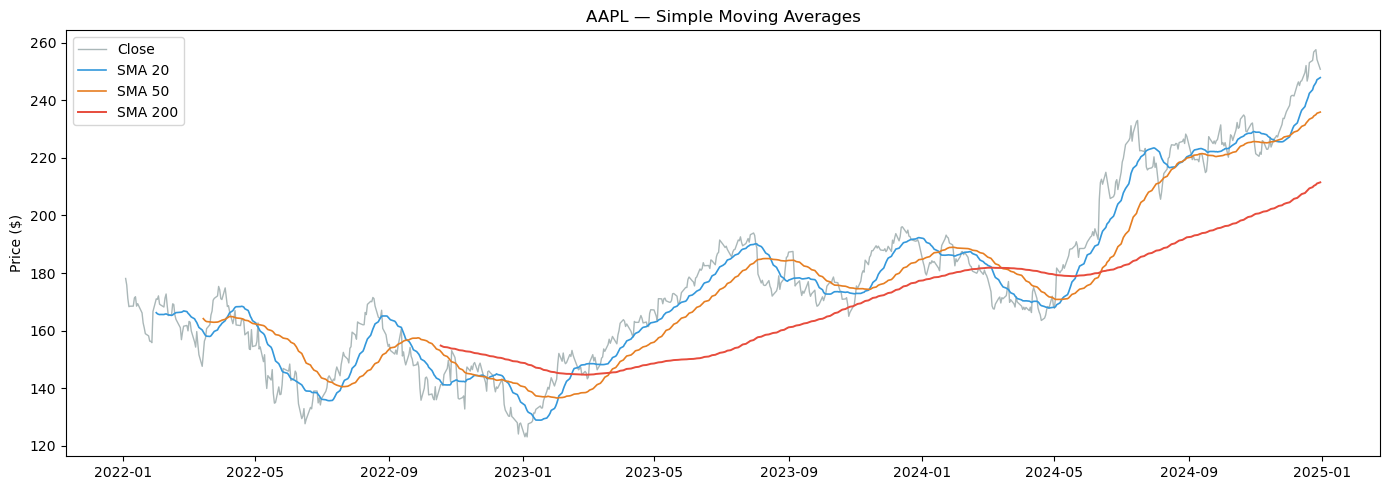

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["Close"],   color="#95a5a6", linewidth=1,   label="Close",   alpha=0.8)
ax.plot(df.index, df["SMA_20"],  color="#3498db", linewidth=1.2, label="SMA 20")
ax.plot(df.index, df["SMA_50"],  color="#e67e22", linewidth=1.2, label="SMA 50")
ax.plot(df.index, df["SMA_200"], color="#e74c3c", linewidth=1.4, label="SMA 200")

ax.set_title(f"{ticker_symbol} — Simple Moving Averages")
ax.set_ylabel("Price ($)")
ax.legend()

plt.tight_layout()
plt.show()

# Close above SMA_200       = long-term uptrend
# Close below SMA_200       = long-term downtrend
# SMA_20 crosses above SMA_50 = Golden Cross (bullish signal)
# SMA_20 crosses below SMA_50 = Death Cross  (bearish signal)
# SMAs bunching together    = trend losing strength, possible reversal

### EMA (Exponential Moving Averages) + Bollinger Bands

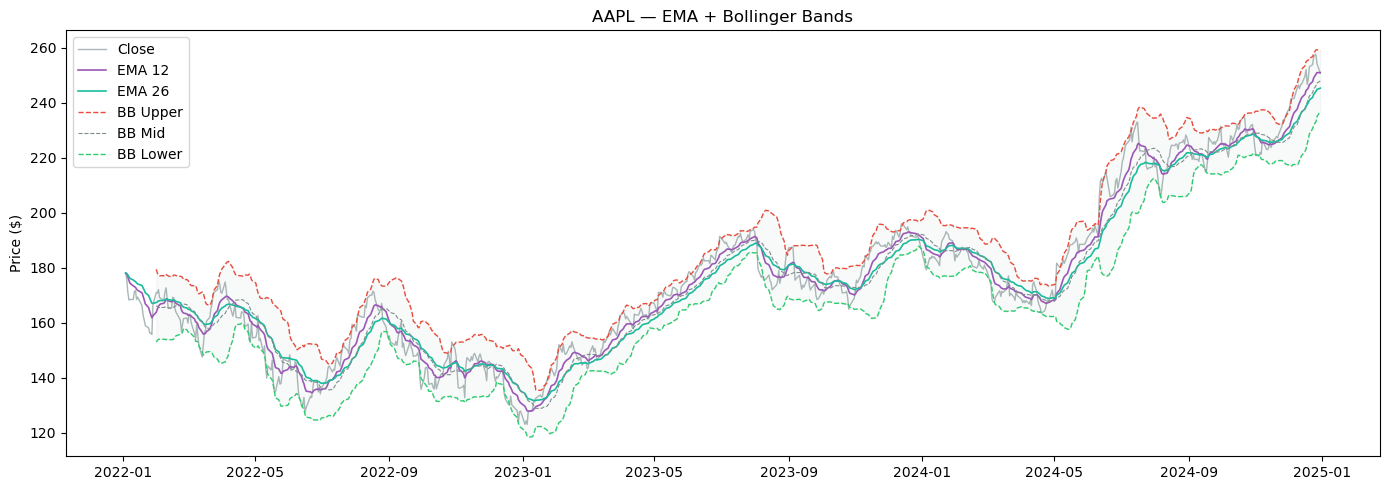

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df.index, df["Close"],    color="#95a5a6", linewidth=1,   label="Close", alpha=0.8)
ax.plot(df.index, df["EMA_12"],   color="#9b59b6", linewidth=1.2, label="EMA 12")
ax.plot(df.index, df["EMA_26"],   color="#1abc9c", linewidth=1.2, label="EMA 26")
ax.plot(df.index, df["BB_Upper"], color="#e74c3c", linewidth=1,   label="BB Upper", linestyle="--")
ax.plot(df.index, df["BB_Mid"],   color="#7f8c8d", linewidth=0.8, label="BB Mid",   linestyle="--")
ax.plot(df.index, df["BB_Lower"], color="#2ecc71", linewidth=1,   label="BB Lower", linestyle="--")
ax.fill_between(df.index, df["BB_Upper"], df["BB_Lower"], alpha=0.05, color="#7f8c8d")

ax.set_title(f"{ticker_symbol} — EMA + Bollinger Bands")
ax.set_ylabel("Price ($)")
ax.legend()

plt.tight_layout()
plt.show()

# Price touching BB_Upper   = price at high end of normal range, may pull back
# Price touching BB_Lower   = price at low end of normal range, may bounce
# Bands narrow (squeeze)    = low volatility, big move likely coming
# Bands widen               = high volatility, market is unsettled
# EMA_12 above EMA_26       = short-term momentum is bullish
# EMA_12 below EMA_26       = short-term momentum is bearish

### RSI (Relative Strength Index)

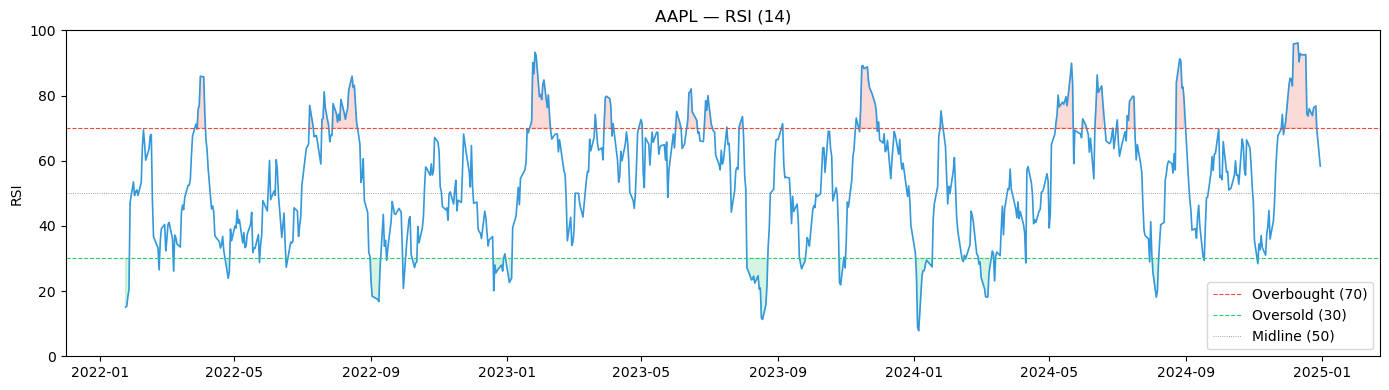

In [16]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, df["RSI"], color="#3498db", linewidth=1.2)
ax.axhline(70, color="#e74c3c", linewidth=0.8, linestyle="--", label="Overbought (70)")
ax.axhline(30, color="#2ecc71", linewidth=0.8, linestyle="--", label="Oversold (30)")
ax.axhline(50, color="#7f8c8d", linewidth=0.6, linestyle=":",  label="Midline (50)")
ax.fill_between(df.index, df["RSI"], 70,
                where=df["RSI"] >= 70, alpha=0.2, color="#e74c3c")
ax.fill_between(df.index, df["RSI"], 30,
                where=df["RSI"] <= 30, alpha=0.2, color="#2ecc71")
ax.set_ylim(0, 100)
ax.set_title(f"{ticker_symbol} — RSI (14)")
ax.set_ylabel("RSI")
ax.legend()

plt.tight_layout()
plt.show()

# RSI above 70 (red zone)   = stock has risen too fast, may be due for a pullback
# RSI below 30 (green zone) = stock has fallen too fast, may be due for a bounce
# RSI crossing 50 upward    = momentum turning bullish
# RSI crossing 50 downward  = momentum turning bearish
# RSI can stay overbought/oversold for long stretches in strong trends — not a
# guaranteed reversal signal on its own, use with other indicators

### MACD (Moving Average Convergence Divergence)

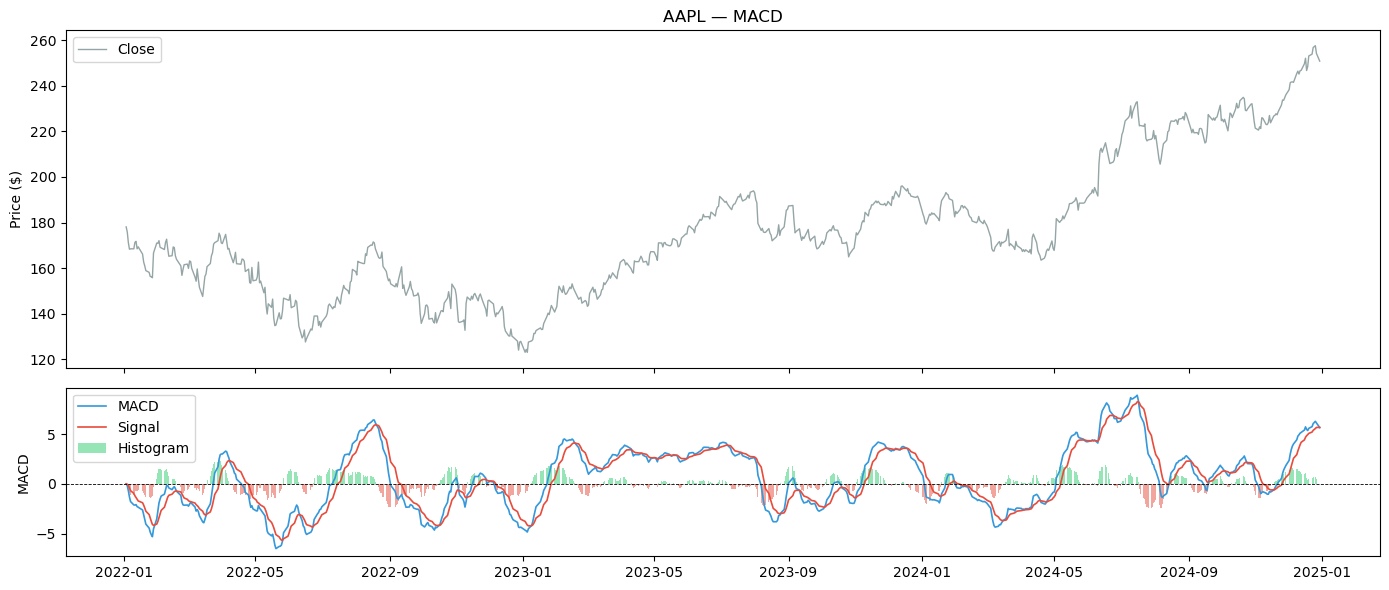

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# Price + signal context on top
axes[0].plot(df.index, df["Close"], color="#95a5a6", linewidth=1, label="Close")
axes[0].set_ylabel("Price ($)")
axes[0].set_title(f"{ticker_symbol} — MACD")
axes[0].legend()

# MACD on bottom
axes[1].plot(df.index, df["MACD"],        color="#3498db", linewidth=1.2, label="MACD")
axes[1].plot(df.index, df["MACD_Signal"], color="#e74c3c", linewidth=1.2, label="Signal")
axes[1].bar(df.index, df["MACD_Hist"],
            color=df["MACD_Hist"].apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
            width=1, alpha=0.5, label="Histogram")
axes[1].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[1].set_ylabel("MACD")
axes[1].legend()

plt.tight_layout()
plt.show()

# MACD crosses above Signal  = bullish crossover, momentum shifting up
# MACD crosses below Signal  = bearish crossover, momentum shifting down
# Histogram above zero       = MACD > Signal, bullish momentum
# Histogram below zero       = MACD < Signal, bearish momentum
# Histogram bars shrinking   = momentum is fading, possible crossover soon
# MACD diverging from price  = price making new highs but MACD isn't = warning sign

## Volume Analysis

### Volume Calculations

In [25]:
# --- Average Volume ---
df["Avg_Volume"] = df["Volume"].rolling(20).mean()

# --- Volume Spike ---
df["Volume_Spike"] = df["Volume"] / df["Avg_Volume"]  # ratio vs average
# anything above 2.0 = more than double average = significant spike

# --- OBV ---
obv = []
obv_value = 0

for i in range(len(df)):
    if i == 0:
        obv.append(0)
    elif df["Close"].iloc[i] > df["Close"].iloc[i - 1]:
        obv_value += df["Volume"].iloc[i]   # up day → add volume
        obv.append(obv_value)
    elif df["Close"].iloc[i] < df["Close"].iloc[i - 1]:
        obv_value -= df["Volume"].iloc[i]   # down day → subtract volume
        obv.append(obv_value)
    else:
        obv.append(obv_value)               # unchanged day → no change

df["OBV"] = obv

print(df[["Close", "Volume", "Avg_Volume", "Volume_Spike", "OBV"]].tail(10))

Price            Close     Volume  Avg_Volume  Volume_Spike         OBV
Date                                                                   
2024-12-16  249.676086   51694800  42354720.0      1.220520  1170568700
2024-12-17  252.102829   51356400  42690855.0      1.202984  1221925100
2024-12-18  246.702347   56774100  43718970.0      1.298615  1165151000
2024-12-19  248.432892   60882300  45004605.0      1.352802  1226033300
2024-12-20  253.107361  147495300  50273955.0      2.933831  1373528600
2024-12-23  253.883118   40858800  50408480.0      0.810554  1414387400
2024-12-24  256.797211   23234700  47062575.0      0.493698  1437622100
2024-12-26  257.612732   27237100  46125120.0      0.590505  1464859200
2024-12-27  254.201355   42355300  46567965.0      0.909537  1422503900
2024-12-30  250.829788   35557500  46921770.0      0.757804  1386946400


### Average volume + volume spike plot

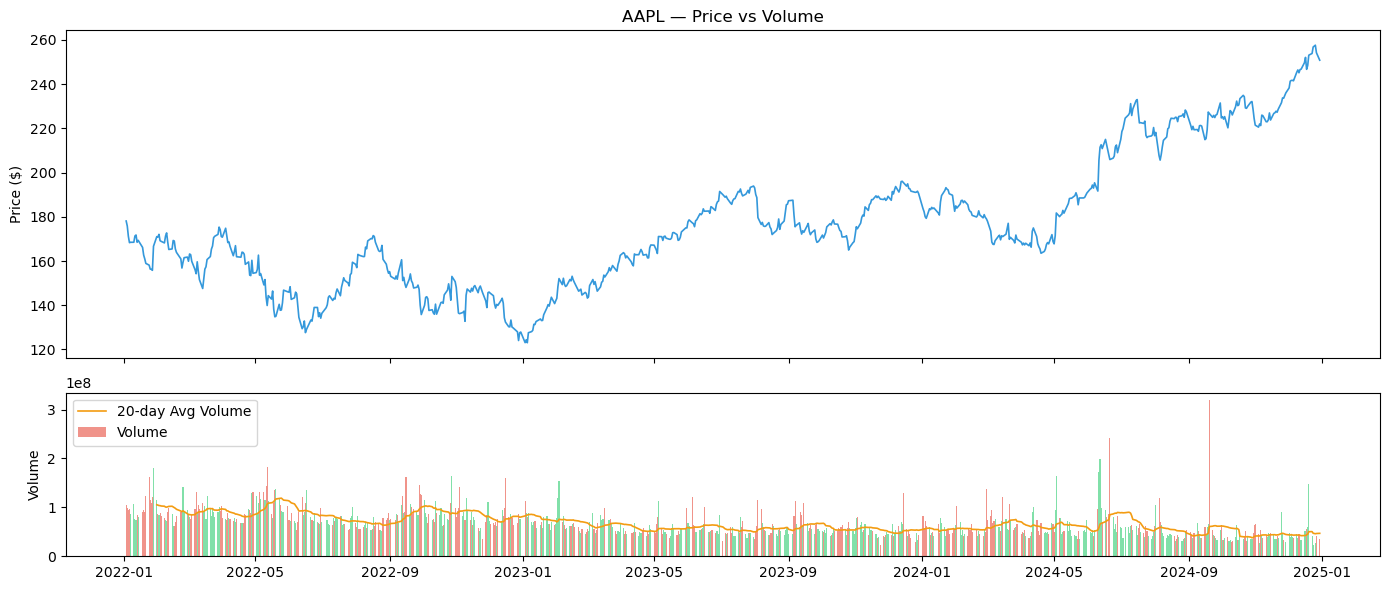

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})

# Price on top for context
axes[0].plot(df.index, df["Close"], color="#3498db", linewidth=1.2)
axes[0].set_title(f"{ticker_symbol} — Price vs Volume")
axes[0].set_ylabel("Price ($)")

# Volume bars + average line on bottom
axes[1].bar(df.index, df["Volume"],
            color=df["Close"].pct_change().apply(lambda x: "#2ecc71" if x >= 0 else "#e74c3c"),
            width=1, alpha=0.6, label="Volume")
axes[1].plot(df.index, df["Avg_Volume"],
             color="#f39c12", linewidth=1.2, label="20-day Avg Volume")
axes[1].set_ylabel("Volume")
axes[1].legend()

plt.tight_layout()
plt.show()

# Green bar       = volume on an up day
# Red bar         = volume on a down day
# Bar well above orange line  = unusually high volume, significant event
# Bar well below orange line  = unusually quiet day, weak conviction
# High volume up day          = strong buying pressure, move is real
# High volume down day        = strong selling pressure, move is real
# Low volume up day           = weak move, may not sustain
# Low volume down day         = weak selling, may not sustain

### Volume spike plot

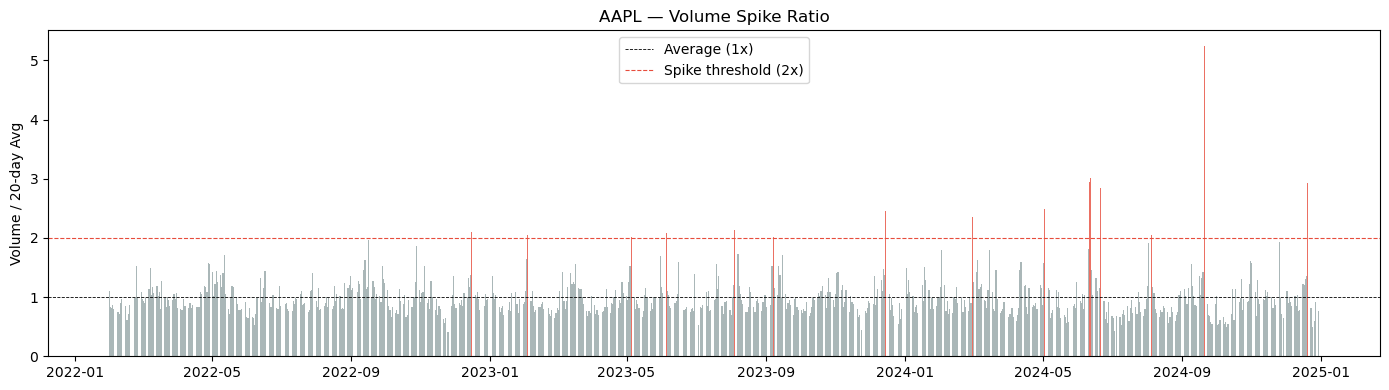

In [27]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df["Volume_Spike"],
       color=df["Volume_Spike"].apply(lambda x: "#e74c3c" if x >= 2 else "#95a5a6"),
       width=1, alpha=0.8)
ax.axhline(1.0, color="black",   linewidth=0.6, linestyle="--", label="Average (1x)")
ax.axhline(2.0, color="#e74c3c", linewidth=0.8, linestyle="--", label="Spike threshold (2x)")
ax.set_title(f"{ticker_symbol} — Volume Spike Ratio")
ax.set_ylabel("Volume / 20-day Avg")
ax.legend()

plt.tight_layout()
plt.show()

# Y-axis is a ratio, not raw volume:
#   1.0 = exactly average volume
#   2.0 = double the average = spike
#   3.0 = triple the average = major event

# Red bars above 2x → significant spike, something happened that day
# Gray bars        → normal volume, nothing unusual
# Spike with price up   → strong buying, move is confirmed
# Spike with price down → strong selling, move is confirmed
# Spike with no price move → accumulation or distribution happening quietly

### OBV (On-balance volume) plot

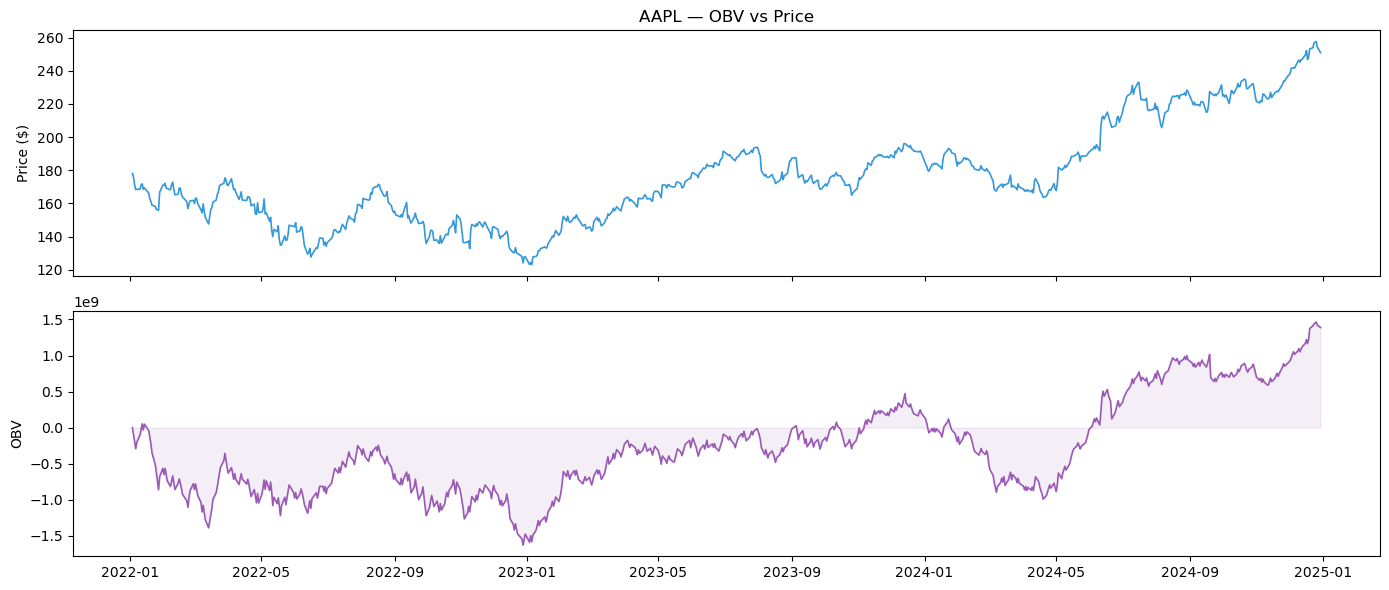

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                          gridspec_kw={"height_ratios": [1, 1]})

# Price on top
axes[0].plot(df.index, df["Close"], color="#3498db", linewidth=1.2)
axes[0].set_title(f"{ticker_symbol} — OBV vs Price")
axes[0].set_ylabel("Price ($)")

# OBV on bottom
axes[1].plot(df.index, df["OBV"], color="#9b59b6", linewidth=1.2)
axes[1].fill_between(df.index, df["OBV"], alpha=0.1, color="#9b59b6")
axes[1].set_ylabel("OBV")

plt.tight_layout()
plt.show()

# OBV rising + price rising  → volume confirming uptrend, healthy move
# OBV falling + price falling→ volume confirming downtrend, healthy move
# OBV rising + price flat    → accumulation, big buyers loading quietly
#                               price breakout likely coming soon
# OBV falling + price flat   → distribution, big sellers offloading quietly
#                               price breakdown likely coming soon
# OBV falling + price rising → divergence, rally not backed by volume
#                               move may be fake, reversal risk is high
# OBV rising + price falling → divergence, selloff not backed by volume
#                               may be false breakdown, bounce possible